# Decision

This notebook runs simulation-only experiments and exports advisor evaluation metrics using pure Python calls (no shell commands).

## 1) Setup paths and imports

In [2]:
from pathlib import Path
import csv
import json
import os

import pandas as pd

from coup.research.advisor_eval import summarize_advisor_metrics
from coup.sim.metrics import calibration_bin_labels, summarize_game
from coup.sim.sim import simulate_games

ROOT = Path.cwd()
if not (ROOT / 'coup').exists():
    fallback = Path('/Users/crishuynh/Documents/SoftwareProject/coup_detection')
    if (fallback / 'coup').exists():
        ROOT = fallback
os.chdir(ROOT)
print('Repository root:', ROOT)

EXPERIMENT_ROOT = ROOT / 'data' / 'research' / 'decision'
EXPERIMENT_ROOT.mkdir(parents=True, exist_ok=True)
print('Experiment root:', EXPERIMENT_ROOT)


Repository root: /Users/crishuynh/Documents/SoftwareProject/coup_detection
Experiment root: /Users/crishuynh/Documents/SoftwareProject/coup_detection/data/research/decision


## 2) Config

In [3]:
CONFIG = {
    'players': 4,
    'games_per_seed': 50,
    'max_turns': 200,
    'bot_mix': None,  # Example: ['honest', 'bluffer', 'aggressive', 'cautious']
    'seeds': [101, 202, 303, 404, 505],
}
CONFIG


{'players': 4,
 'games_per_seed': 50,
 'max_turns': 200,
 'bot_mix': None,
 'seeds': [101, 202, 303, 404, 505]}

## 3) Run one seed and write `summary.csv`

In [4]:
def run_seed_simulation(seed: int, out_dir: Path) -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    results = simulate_games(
        CONFIG['games_per_seed'],
        players=CONFIG['players'],
        seed=seed,
        bot_mix=CONFIG['bot_mix'],
        max_turns=CONFIG['max_turns'],
    )

    histogram_columns = calibration_bin_labels()
    summary_rows = []

    for idx, result in enumerate(results, start=1):
        (out_dir / f'game_{idx}.json').write_text(json.dumps(result.events, indent=2))
        metrics = summarize_game(
            events=result.events,
            players=result.players,
            winner=result.winner,
            turns=result.turns,
        )
        row = {
            'game': idx,
            'seed': seed + idx - 1,
            'players': len(result.players),
            'bot_mix': ','.join(result.bot_styles),
            'winner': metrics.winner,
            'turns': metrics.turns,
            'challenges': metrics.challenges,
            'challenge_accuracy': round(metrics.challenge_accuracy, 4),
            'advisor_agreement_rate': round(metrics.advisor_agreement_rate, 4),
            'advisor_claims_total': metrics.advisor_claims_total,
            'advisor_recommended_challenges': metrics.advisor_recommended_challenges,
            'advisor_actual_challenges': metrics.advisor_actual_challenges,
            'advisor_challenge_precision': round(metrics.advisor_challenge_precision, 4),
            'advisor_challenge_recall': round(metrics.advisor_challenge_recall, 4),
            'advisor_challenge_f1': round(metrics.advisor_challenge_f1, 4),
            'advisor_challenge_accuracy': round(metrics.advisor_challenge_accuracy, 4),
            'advisor_outcome_accuracy': round(metrics.advisor_outcome_accuracy, 4),
            'advisor_outcome_score': round(metrics.advisor_outcome_score, 4),
        }
        for key in histogram_columns:
            row[f'reveal_prob_bin_{key}'] = metrics.reveal_prob_histogram.get(key, 0)
        summary_rows.append(row)

    summary_csv = out_dir / 'summary.csv'
    with summary_csv.open('w', newline='') as handle:
        writer = csv.DictWriter(handle, fieldnames=list(summary_rows[0].keys()))
        writer.writeheader()
        writer.writerows(summary_rows)

    return summary_csv


## 4) Run multi-seed experiment and aggregate advisor metrics

In [5]:
seed_rows = []

for seed in CONFIG['seeds']:
    seed_dir = EXPERIMENT_ROOT / f'seed_{seed}'
    summary_csv = run_seed_simulation(seed, seed_dir)
    report = summarize_advisor_metrics(summary_csv, out_dir=seed_dir / 'advisor_eval')

    metrics = report['metrics']
    seed_rows.append({
        'seed': seed,
        'games': report['games'],
        'challenge_f1_mean': metrics['advisor_challenge_f1']['mean'],
        'challenge_precision_mean': metrics['advisor_challenge_precision']['mean'],
        'challenge_recall_mean': metrics['advisor_challenge_recall']['mean'],
        'outcome_accuracy_mean': metrics['advisor_outcome_accuracy']['mean'],
        'outcome_score_mean': metrics['advisor_outcome_score']['mean'],
    })

seed_df = pd.DataFrame(seed_rows).sort_values("seed")
seed_df.to_csv(EXPERIMENT_ROOT / 'advisor_multiseed_results.csv', index=False)
seed_df


,seed,games,challenge_f1_mean,challenge_precision_mean,challenge_recall_mean,outcome_accuracy_mean,outcome_score_mean
0,101,50,0.402888,0.350418,0.586144,0.600048,0.200096
1,202,50,0.371896,0.323726,0.567998,0.570238,0.140474
2,303,50,0.393014,0.328712,0.556238,0.555618,0.111240
3,404,50,0.412460,0.357730,0.580574,0.584954,0.169904
4,505,50,0.405912,0.337320,0.581712,0.512334,0.024666


## 5) Thesis summary table (mean ± std across seeds)

In [6]:
summary = {
    'challenge_f1': (seed_df['challenge_f1_mean'].mean(), seed_df['challenge_f1_mean'].std(ddof=0)),
    'challenge_precision': (seed_df['challenge_precision_mean'].mean(), seed_df['challenge_precision_mean'].std(ddof=0)),
    'challenge_recall': (seed_df['challenge_recall_mean'].mean(), seed_df['challenge_recall_mean'].std(ddof=0)),
    'outcome_accuracy': (seed_df['outcome_accuracy_mean'].mean(), seed_df['outcome_accuracy_mean'].std(ddof=0)),
    'outcome_score': (seed_df['outcome_score_mean'].mean(), seed_df['outcome_score_mean'].std(ddof=0)),
}

thesis_rows = []
for metric, (mean, std) in summary.items():
    thesis_rows.append({
        'metric': metric,
        'mean': round(float(mean), 4),
        'std': round(float(std), 4),
        'mean_plus_minus_std': f'{float(mean):.4f} ± {float(std):.4f}',
    })

thesis_df = pd.DataFrame(thesis_rows)
thesis_df.to_csv(EXPERIMENT_ROOT / 'advisor_multiseed_thesis_table.csv', index=False)
thesis_df


,metric,mean,std,mean_plus_minus_std
0,challenge_f1,0.3972,0.0141,0.3972 ± 0.0141
1,challenge_precision,0.3396,0.0128,0.3396 ± 0.0128
2,challenge_recall,0.5745,0.0110,0.5745 ± 0.0110
3,outcome_accuracy,0.5646,0.0301,0.5646 ± 0.0301
4,outcome_score,0.1293,0.0601,0.1293 ± 0.0601


## 6) plot

Saved plot: /Users/crishuynh/Documents/SoftwareProject/coup_detection/data/research/decision/advisor_multiseed_plot.png


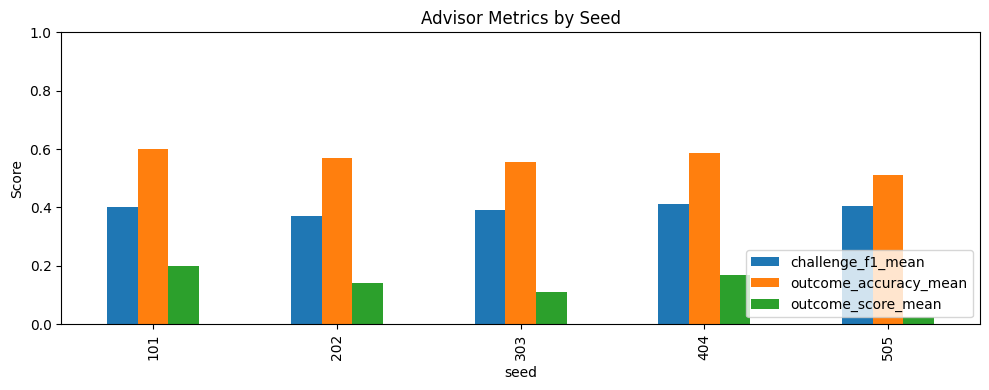

In [7]:
import matplotlib.pyplot as plt

plot_cols = ['challenge_f1_mean', 'outcome_accuracy_mean', 'outcome_score_mean']
ax = seed_df.set_index('seed')[plot_cols].plot(kind='bar', figsize=(10, 4))
ax.set_title('Advisor Metrics by Seed')
ax.set_ylim(0.0, 1.0)
ax.set_ylabel('Score')
ax.legend(loc="lower right")
plt.tight_layout()
plot_path = EXPERIMENT_ROOT / 'advisor_multiseed_plot.png'
plt.savefig(plot_path, dpi=140)
print('Saved plot:', plot_path)


## 7) Bot-Mix Robustness Comparison (side-by-side)

In [8]:
def run_seed_simulation_with_mix(seed: int, out_dir: Path, bot_mix: list[str] | None) -> Path:
    original_mix = CONFIG.get('bot_mix')
    CONFIG['bot_mix'] = bot_mix
    try:
        return run_seed_simulation(seed, out_dir)
    finally:
        CONFIG['bot_mix'] = original_mix

BOT_MIX_CONDITIONS = [
    {'name': 'honest_heavy', 'bot_mix': ['honest', 'honest', 'cautious', 'honest']},
    {'name': 'aggressive_heavy', 'bot_mix': ['aggressive', 'aggressive', 'bluffer', 'aggressive']},
]
BOT_MIX_CONDITIONS


[{'name': 'honest_heavy',
  'bot_mix': ['honest', 'honest', 'cautious', 'honest']},
 {'name': 'aggressive_heavy',
  'bot_mix': ['aggressive', 'aggressive', 'bluffer', 'aggressive']}]

In [9]:
condition_rows = []

for condition in BOT_MIX_CONDITIONS:
    cond_name = condition['name']
    cond_mix = condition['bot_mix']
    cond_root = EXPERIMENT_ROOT / f'condition_{cond_name}'
    seed_rows = []

    for seed in CONFIG['seeds']:
        seed_dir = cond_root / f'seed_{seed}'
        summary_csv = run_seed_simulation_with_mix(seed, seed_dir, cond_mix)
        report = summarize_advisor_metrics(summary_csv, out_dir=seed_dir / 'advisor_eval')
        metrics = report['metrics']
        seed_rows.append({
            'seed': seed,
            'condition': cond_name,
            'challenge_f1_mean': metrics['advisor_challenge_f1']['mean'],
            'challenge_precision_mean': metrics['advisor_challenge_precision']['mean'],
            'challenge_recall_mean': metrics['advisor_challenge_recall']['mean'],
            'outcome_accuracy_mean': metrics['advisor_outcome_accuracy']['mean'],
            'outcome_score_mean': metrics['advisor_outcome_score']['mean'],
        })

    seed_df_cond = pd.DataFrame(seed_rows)
    seed_df_cond.to_csv(cond_root / 'condition_seed_results.csv', index=False)

    condition_rows.append({
        'condition': cond_name,
        'bot_mix': ','.join(cond_mix),
        'challenge_f1_mean': float(seed_df_cond['challenge_f1_mean'].mean()),
        'challenge_f1_std': float(seed_df_cond['challenge_f1_mean'].std(ddof=0)),
        'outcome_accuracy_mean': float(seed_df_cond['outcome_accuracy_mean'].mean()),
        'outcome_accuracy_std': float(seed_df_cond['outcome_accuracy_mean'].std(ddof=0)),
        'outcome_score_mean': float(seed_df_cond['outcome_score_mean'].mean()),
        'outcome_score_std': float(seed_df_cond['outcome_score_mean'].std(ddof=0)),
    })

condition_comparison_df = pd.DataFrame(condition_rows).sort_values("condition")
condition_comparison_df.to_csv(EXPERIMENT_ROOT / 'advisor_bot_mix_comparison.csv', index=False)
condition_comparison_df


,condition,bot_mix,challenge_f1_mean,challenge_f1_std,outcome_accuracy_mean,outcome_accuracy_std,outcome_score_mean,outcome_score_std
1,aggressive_heavy,"aggressive,aggressive,bluffer,aggressive",0.564148,0.014384,0.561944,0.021958,0.123886,0.043917
0,honest_heavy,"honest,honest,cautious,honest",0.311417,0.009467,0.536600,0.028187,0.073200,0.056371


## 8) Outputs
- Per-seed folders: `data/research/decision/seed_<seed>/...`
- Aggregate CSV: `advisor_multiseed_results.csv`
- Thesis table: `advisor_multiseed_thesis_table.csv`
- Plot: `advisor_multiseed_plot.png`
- Bot-mix comparison CSV: `advisor_bot_mix_comparison.csv`\n

In [10]:
from pathlib import Path
import shutil
from datetime import datetime

root = Path("/Users/crishuynh/Documents/SoftwareProject/coup_detection/data/research")
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
freeze = root / "frozen_runs" / stamp
freeze.mkdir(parents=True, exist_ok=True)

for name in ["advisor_experiments", "dqn_rl_fit"]:
    src = root / name
    if src.exists():
        shutil.copytree(src, freeze / name)

print("Frozen to:", freeze)


Frozen to: /Users/crishuynh/Documents/SoftwareProject/coup_detection/data/research/frozen_runs/20260409_135857
